In [3]:
import inspect
from functools import wraps
from typing import Any, Callable

import numpy as np

OBJECTIVE_REGISTRY = {}
SEED = None
rng = np.random.default_rng(SEED)

class ObjectiveFunction:
    def __init__(self, name: str, func: Callable, data: dict) -> None:
        self.name = name
        self.func = func
        self.data = data

    def __call__(self, x: np.ndarray, y: np.ndarray) -> np.ndarray:
        return self.func(x, y, **self.data)


def register_objective(name: str | None = None, **data) -> Callable[..., Any]:
    def decorator(func: Callable[..., Any]) -> Callable[..., Any]:
        sig = inspect.signature(func)
        params = list(sig.parameters.keys())[2:]  # skip X and Y
        func_name = name or func.__name__

        @wraps(func)
        def factory(*args, **kwargs) -> ObjectiveFunction:
            missing = [k for k in params if k not in data and k not in kwargs]
            if missing:
                raise ValueError(f"Missing keys for '{name}': {missing}")
            return ObjectiveFunction(func_name, func, {**data, **kwargs})

        OBJECTIVE_REGISTRY[func_name] = factory
        return func

    return decorator


In [4]:
from typing import Iterable

import numpy as np

n_pokemon = 1302
n_moves = 459
n_types = 18
n_stats = 6

ME = rng.integers(20, 110, size=(2, n_moves), dtype=np.int16, endpoint=True)  # Replace with actual - Move Effectiveness
# Make sure ME has only one value per column
rows = rng.integers(0, 1, size=ME.shape[1], endpoint=True)
ME[rows, np.arange(ME.shape[1])] = 0


@register_objective(me=ME)
def test_objective(x: np.ndarray, y: np.ndarray, me: np.ndarray) -> int:
    """ Objective function that sums the effectiveness of moves selected by y."""
    prefilter_move_columns = y.flatten()
    valid_mask = prefilter_move_columns != -1
    move_columns = prefilter_move_columns[valid_mask]
    return ME[:, move_columns].sum()

@register_objective(me=ME)
def test_objective2(x: np.ndarray, y: np.ndarray, me: np.ndarray) -> int:
    """ Objective function that returns the maximum effectiveness of moves selected by y."""
    prefilter_move_columns = y.flatten()
    valid_mask = prefilter_move_columns != -1
    move_columns = prefilter_move_columns[valid_mask]
    return ME[:, move_columns].max()


class ObjectiveSelector:
    def __init__(self, objective_names: Iterable[str]) -> None:
        assert all(name in OBJECTIVE_REGISTRY for name in objective_names), \
            f"Some objectives are not registered: {set(objective_names) - set(OBJECTIVE_REGISTRY.keys())}"
        self.objectives = [OBJECTIVE_REGISTRY[name]() for name in objective_names]
        self.n_obj = len(self.objectives)

    def evaluate(self, x: np.ndarray, y: np.ndarray) -> list:
        return [-obj(x, y) for obj in self.objectives]


selector = ObjectiveSelector(["test_objective", "test_objective2"])


In [5]:
# 6x4 Implementation of Pokémon Team Problem with Constraints
import numpy as np
from numpy._typing._array_like import NDArray
from pymoo.algorithms.moo.nsga2 import NSGA2
from pymoo.core.crossover import Crossover
from pymoo.core.mutation import Mutation
from pymoo.core.problem import Problem
from pymoo.core.sampling import Sampling
from pymoo.optimize import minimize
from pymoo.termination import get_termination

# === CONFIGURATION ===
LM = rng.integers(0, 2, size=(n_pokemon, n_moves), dtype=bool)  # Replace with actual - Learnable Moves
PT = rng.integers(0, 2, size=(n_pokemon, n_types), dtype=bool)  # Replace with actual - Pokémon Types
MT = rng.integers(0, 2, size=(n_moves, n_types), dtype=bool)  # Replace with actual - Move Types
PS = rng.integers(20, 110, size=(n_pokemon, n_stats), dtype=np.int16, endpoint=True)  # Replace with actual - Pokémon Stats
Att = [
    0,
    1,
    1,
    0,
    0,
    0,
]  # Replace with actual - Vector to chose attack and special attack stats


# === PROBLEM WITH CONSTRAINTS ===
class PokemonProblem(Problem):
    def __init__(
        self,
        objectives: ObjectiveSelector,
        lm: NDArray[np.bool_] = LM,
        n_pokemon: int = n_pokemon,
        n_moves: int = n_moves,
        repeat_pokemon: bool = False,
        pokemon_in_team: int = 6,
    ) -> None:
        self.n_pokemon = n_pokemon
        self.n_moves = n_moves
        self.objectives = objectives
        self.LM = lm.astype(bool)
        self.repeat_pokemon = repeat_pokemon
        self.pokemon_in_team = pokemon_in_team
        super().__init__(
            n_var=self.pokemon_in_team + self.pokemon_in_team * 4,  # Num pokemon + Num Pokemon * 4 moves
            n_obj=self.objectives.n_obj,
            n_ieq_constr=self.pokemon_in_team * 4
            + self.pokemon_in_team
            + 1 * self.repeat_pokemon,  # The 4 moves of each 6 pokemon must be learnable. Each pokemon has 4 different moves
            xl=0,
            xu=n_pokemon,
            type_var=np.uint16,
        )

    def _evaluate(self, X: NDArray[np.uint16], out: dict, *args, **kwargs) -> None:  # noqa: N803
        F = []
        G = []

        for ind in X:
            x = ind[: self.pokemon_in_team]
            y = ind[self.pokemon_in_team :].reshape(self.pokemon_in_team, 4)

            # === Objectives ===
            # x contains the row indexes, y contains the column indexes for ME
            # For each pair (xi, yi), sum ME[xi, yi]

            prefilter_pokemon_rows = np.repeat(x, 4)
            prefilter_move_columns = y.flatten()
            # Filter out moves with value -1 and their corresponding pokemon_rows
            valid_mask = prefilter_move_columns != -1
            pokemon_rows = prefilter_pokemon_rows[valid_mask]
            move_columns = prefilter_move_columns[valid_mask]
            F.append(self.objectives.evaluate(x, y))  # negative = maximize

            # === Constraints ===
            constraints = []

            # Moves in the positions of x_i and y_i are learnable: 1 - LM_xi,yi ≤ 0
            constraints += list((1 - self.LM[pokemon_rows, move_columns]).flatten())

            # Not repeated moves: len(yi) - len(set(yi)) ≤ 0
            constraints += list((np.apply_along_axis(lambda row: len(row[row >= 0]) - len(set(row[row >= 0])), 1, y)))

            # no repeated Pokemon: len(x) - len(set(x)) ≤ 0
            if self.repeat_pokemon:
                constraints += list((len(set(x)) - len(x)).flatten())

            G.append(constraints)

        out["F"] = np.array(F)
        out["G"] = np.array(G)


def get_random_moves(lm: np.ndarray, i: int) -> np.ndarray[np.int16]:
    legal_moves = np.where(lm[i])[0]
    chosen = -1 * np.ones(4, dtype=np.int16)
    if len(legal_moves) >= 4:
        selected = rng.choice(legal_moves, size=4, replace=False)
    else:
        # Optional: fallback to random other Pokémon if not enough moves
        selected = rng.choice(legal_moves, size=len(legal_moves), replace=False)
    chosen[: selected.shape[0]] = selected
    return chosen


class PokemonTeamSampling(Sampling):
    def __init__(self) -> None:
        super().__init__()

    def _do(self, problem: PokemonProblem, n_samples: int, **kwargs) -> NDArray[np.uint16]:
        individuals = []

        for _ in range(n_samples):
            # (1) Select 6 unique Pokémon
            team = rng.choice(problem.n_pokemon, problem.pokemon_in_team, replace=False)

            # (2) Assign 4 legal moves to each selected Pokémon
            moves = np.zeros((problem.pokemon_in_team, 4), dtype=np.int16)

            for j, i in enumerate(team):
                legal_moves = np.where(problem.LM[i])[0]
                chosen = -1 * np.ones(4, dtype=np.int16)
                if len(legal_moves) >= 4:
                    selected = rng.choice(legal_moves, size=4, replace=False)
                else:
                    # Optional: fallback to random other Pokémon if not enough moves
                    selected = rng.choice(legal_moves, size=len(legal_moves), replace=False)
                chosen[: selected.shape[0]] = selected
                moves[j] = chosen

            # Flatten and concatenate
            indiv = np.concatenate([team, moves.flatten()])
            individuals.append(indiv)

        return np.array(individuals)


class PokemonMutation(Mutation):
    def __init__(self, prob_pokemon: float = 0.01, prob_move: float = 0.001) -> None:
        super().__init__()
        self.prob_pokemon = prob_pokemon
        self.prob_move = prob_move

    def pokemon_mutation(self, x: NDArray[np.uint16], y: NDArray[np.int16], lm: NDArray[np.bool_]) -> tuple[NDArray[np.uint16], NDArray[np.int16]]:
        not_chosen_pokemon = [i for i in range(lm.shape[0]) if i not in x]
        possible_new_pokemon = rng.choice(not_chosen_pokemon, size=x.shape[0], replace=False)

        mutated_pokemon_mask = rng.random(x.shape[0]) < self.prob_pokemon
        mutated_team = np.where(
            mutated_pokemon_mask,
            possible_new_pokemon,
            x,
        )

        mutated_moves = y.copy()
        for j, i in enumerate(mutated_team):
            if mutated_pokemon_mask[j]:
                mutated_moves[j] = get_random_moves(LM, i)
        return mutated_team, mutated_moves

    def move_mutation(self, x: NDArray[np.uint16], y: NDArray[np.int16], lm: NDArray[np.bool_]) -> NDArray[np.int16]:
        pokemon_in_team = x.shape[0]
        mutated_moves_mask = rng.random((y.shape[0], y.shape[1])) < self.prob_move
        rows_with_mutations = np.any(mutated_moves_mask, axis=1)
        pokemon_with_mutations = x[rows_with_mutations]
        possible_new_moves = np.zeros((pokemon_in_team, 4), dtype=np.int16)
        modified_LM = self.modify_lm(x, y, lm)
        for i in pokemon_with_mutations:
            possible_new_moves[np.where(x == i)[0][0]] = get_random_moves(modified_LM, i)
        mutated_moves = np.where(
            np.logical_and(mutated_moves_mask, possible_new_moves >= 0),
            possible_new_moves,
            y,
        )
        return mutated_moves

    def modify_lm(self, x: NDArray[np.uint16], y: NDArray[np.int16], lm: NDArray[np.bool_]) -> NDArray[np.bool_]:
        modified_LM = lm.copy()
        num_moves_available = modified_LM.sum(axis=1)[x]
        for x_i, x_val in enumerate(x):
            curren_available_moves = num_moves_available[x_i]
            for y_i in y[x_i]:
                if curren_available_moves > 4:
                    modified_LM[x_val, y_i] = 0
                    curren_available_moves -= 1
                else:
                    break
        return modified_LM

    def _do(self, problem: PokemonProblem, X: NDArray[np.uint16], **kwargs) -> NDArray[np.uint16]:  # noqa: N803
        for ind in X:
            x = ind[: problem.pokemon_in_team]
            y = ind[problem.pokemon_in_team :].reshape(problem.pokemon_in_team, 4)
            mutated_team = x.copy()
            mutated_moves = y.copy()

            mutated_team, mutated_moves = self.pokemon_mutation(x, y, problem.LM)

            # ==== Move mutation ====
            mutated_moves = self.move_mutation(mutated_team, mutated_moves, problem.LM)

            ind[: problem.pokemon_in_team] = mutated_team
            ind[problem.pokemon_in_team :] = mutated_moves.flatten()

        return X


class PokemonCrossover(Crossover):
    def __init__(self, prob_pokemon: float = 0.5) -> None:
        super().__init__(2, 2)  # 2 parents → 2 offspring
        self.prob_pokemon = prob_pokemon

    def _do(self, problem: PokemonProblem, X: NDArray[np.uint16], **kwargs) -> NDArray[np.uint16]:  # noqa: N803
        _, n_matings, _ = X.shape
        pokemon_in_team = problem.pokemon_in_team

        offspring = np.empty_like(X)

        

        for k in range(n_matings):
            parent1 = X[0][k]
            parent2 = X[1][k]

            # CASE 1: If both parents are identical, just copy them
            if np.all(parent1 == parent2):
                offspring[0][k] = parent1.copy()
                offspring[1][k] = parent2.copy()
                continue

            # Split into X and Y
            x1, y1 = (
                parent1[:pokemon_in_team],
                parent1[pokemon_in_team:].reshape(pokemon_in_team, 4),
            )
            x2, y2 = (
                parent2[:pokemon_in_team],
                parent2[pokemon_in_team:].reshape(pokemon_in_team, 4),
            )

            parent1_src1 = rng.random() < self.prob_pokemon  # True if child1 is based on parent 1, False if based on parent 2
            parent1_src2 = rng.random() > self.prob_pokemon  # True if child2 is based on parent 1, False if based on parent 2
            child1 = parent1.copy() if parent1_src1 else parent2.copy()
            child2 = parent1.copy() if parent1_src2 else parent2.copy()

            child1_x, child1_y = (
                child1[:pokemon_in_team],
                child1[pokemon_in_team:].reshape(pokemon_in_team, 4),
            )
            child2_x, child2_y = (
                child2[:pokemon_in_team],
                child2[pokemon_in_team:].reshape(pokemon_in_team, 4),
            )

            # --- Perform crossover on x (pokémon IDs) ---
            n_crossovers_max = rng.integers(1, pokemon_in_team - 1)
            common = set(x1) & set(x2)
            indexes_from1 = x2 if parent1_src1 else x1
            indexes_from2 = x2 if parent1_src2 else x1
            indices1 = [i for i in range(len(x1)) if indexes_from1[i] not in common]
            indices2 = [j for j in range(len(x2)) if indexes_from2[j] not in common]
            rng.shuffle(indices1)
            rng.shuffle(indices2)
            n_crossovers = min(n_crossovers_max, len(indices1), len(indices2))
            done_crossovers = 0
            for i1, i2 in zip(indices1[:n_crossovers], indices2[:n_crossovers]):
                val1 = x2[i1] if parent1_src1 else x1[i1]
                val2 = x2[i2] if parent1_src2 else x1[i2]
                if val1 not in child1_x:
                    if val2 not in child2_x:
                        m1 = y2[i1] if parent1_src1 else y1[i1]
                        m2 = y2[i2] if parent1_src2 else y1[i2]
                        child1_x[i1], child2_x[i2] = val1, val2
                        child1_y[i1], child2_y[i2] = (
                            m1.copy(),
                            m2.copy(),
                        )
                        done_crossovers += 1
                        # print(f"Done crossovers: {done_crossovers}/{n_crossovers}")

            # Combine x and y back into flattened vectors
            offspring[0][k] = np.concatenate([child1_x, child1_y.flatten()])
            offspring[1][k] = np.concatenate([child2_x, child2_y.flatten()])

        return offspring


# === ALGORITHM SETUP ===
algorithm = NSGA2(
    pop_size=100,
    sampling=PokemonTeamSampling(),
    crossover=PokemonCrossover(prob_pokemon=0.5),
    mutation=PokemonMutation(prob_pokemon=0.5, prob_move=0.5),
    eliminate_duplicates=True,
)

termination = get_termination("n_gen", 100)

res = minimize(
    problem=PokemonProblem(objectives=selector, lm=LM, n_pokemon=n_pokemon, n_moves=n_moves),
    algorithm=algorithm,
    termination=termination,
    seed=SEED,
    verbose=True,
    save_history=True,
)

# === RESULTS ===
print("Best solutions on Pareto front:")
if len(res.F) > 2:
    for f, x in zip(res.F, res.X):
        print(f, "(Pokémon count:", x[:n_pokemon].sum(), ")")
else:
    print(res.F, "(Pokémon count:", res.X[:n_pokemon].sum(), ")")


n_gen  |  n_eval  | n_nds  |     cv_min    |     cv_avg    |      eps      |   indicator  
     1 |      100 |      3 |  0.000000E+00 |  0.000000E+00 |             - |             -
     2 |      200 |      2 |  0.000000E+00 |  0.000000E+00 |  0.4065934066 |         ideal
     3 |      300 |      3 |  0.000000E+00 |  0.000000E+00 |  0.0666666667 |         ideal
     4 |      400 |      3 |  0.000000E+00 |  0.000000E+00 |  0.0975609756 |         nadir
     5 |      500 |      3 |  0.000000E+00 |  0.000000E+00 |  0.5176470588 |         ideal
     6 |      600 |      3 |  0.000000E+00 |  0.000000E+00 |  0.5572916667 |         ideal
     7 |      700 |      2 |  0.000000E+00 |  0.000000E+00 |  0.3426573427 |         nadir
     8 |      800 |      2 |  0.000000E+00 |  0.000000E+00 |  0.000000E+00 |             f
     9 |      900 |      3 |  0.000000E+00 |  0.000000E+00 |  0.1876601654 |             f
    10 |     1000 |      3 |  0.000000E+00 |  0.000000E+00 |  0.6067415730 |         nadir

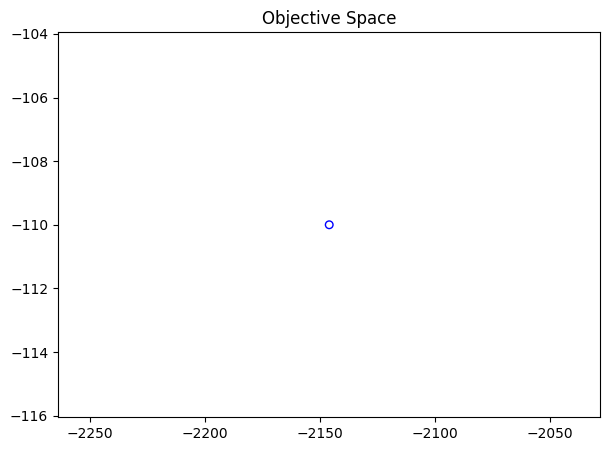

In [6]:
import matplotlib.pyplot as plt

F = res.F
plt.figure(figsize=(7, 5))
plt.scatter(F[:, 0], F[:, 1], s=30, facecolors='none', edgecolors='blue')
plt.title("Objective Space")
plt.show()


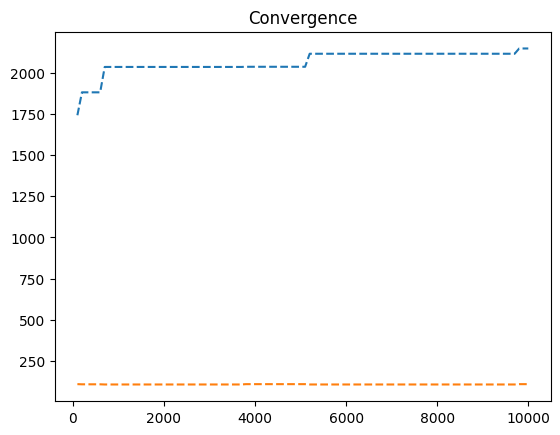

In [7]:
import matplotlib.pyplot as plt
import numpy as np

n_evals = np.array([e.evaluator.n_eval for e in res.history])
opt = np.array([e.opt[0].F for e in res.history])

plt.title("Convergence")
plt.plot(n_evals, abs(opt), "--")
plt.show()
